# Backprop from Scratch: a Tiny Autograd Engine

Chapter 00 ended with a network that had capacity but no knowledge. Knowledge enters
through *gradients*: how much each of the (possibly billions of) parameters should move to
reduce the loss. This chapter builds the machine that computes all of them at once:

1. **Derivative = nudge** — finite differences, the ground truth
2. **The chain rule on a graph** — gradients flow backward through composition
3. **A `Value` class** — ~60 lines that do what `loss.backward()` does
4. **The PyTorch bridge** — same expression, same gradients, `assert allclose`

### Concepts covered

| # | Concept | What to watch for |
|---|---------|-------------------|
| 1 | Finite differences | Slow but trustworthy — the oracle we check everything against |
| 2 | Computation graph | Every op records its inputs; the graph *is* the tape |
| 3 | Chain rule | Local derivative × downstream gradient, at every node |
| 4 | Gradient accumulation | `grad +=`, never `=` — the classic from-scratch bug |
| 5 | Topological order | Why a node's `_backward` may only run after all its consumers |

Reference: [Rumelhart, Hinton & Williams (1986)](https://doi.org/10.1038/323533a0) · [micrograd](https://github.com/karpathy/micrograd) · [docs/PAPERS.md](../../docs/PAPERS.md)

::: {.callout-tip title="📺 Video companion"}
[The spelled-out intro to neural networks and backpropagation (Karpathy)](https://www.youtube.com/watch?v=VMj-3S1tku0)
builds this exact engine in 2.5 hours of live code; 3Blue1Brown's
[backpropagation, intuitively](https://www.youtube.com/watch?v=Ilg3gGewQ5U) and
[backpropagation calculus](https://www.youtube.com/watch?v=tIeHLnjs5U8) are the visual
version — more in [Videos](../../docs/VIDEOS.md).
:::

::: {.callout-note title="🎯 Goal — why this chapter, for the capstone"}
At milestone M4 you will type `loss.backward()` and train *your own* LLM
([Training From Scratch](../02_training_optimization/00_training_from_scratch.ipynb)). That
one line is this chapter: reverse-mode differentiation over a recorded computation graph,
vectorized. Owning the scalar version is what makes the later chapters mechanical rather
than magical — mixed precision (chapter 2.2) is about *where* these gradients lose bits;
gradient accumulation (2.3) is literally this chapter's `grad +=` across microbatches; the
activation memory that pins your GPU budget is the graph this chapter records.

🏗️ **Chapter milestone:** none — but the engine built here is the one M0
([chapter 03](03_softmax_crossentropy.ipynb)) checks against PyTorch to six decimal places.
:::

::: {.callout-tip title="⏱️ Session S0.2" appearance="simple"}
One session: read and run everything, then verify one hand-derived gradient with `Value`.
Cards, prerequisites, and done-when tests: the [Session Guide](../../docs/SESSIONS.md).
:::

<a href="https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/00_dnn_refresher/01_backprop_micrograd.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In [1]:
#| code-fold: true
#| code-summary: "Setup"
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

%config InlineBackend.figure_format = 'retina'
from ai_playground.plotting import apply_plot_style
apply_plot_style()

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

## 1. A derivative is a nudge

Forget symbols for a second: the derivative of `f` at `x` answers *"if I nudge `x` a
little, how much does `f` move?"*. That definition is directly computable — nudge and
measure. Finite differences are too slow to train with (one probe per parameter per step —
7 billion forward passes for one update of a 7B model), but they are simple enough to
trust, which makes them our oracle for everything that follows.

numeric  df/dx at 3.0 = 14.000000
analytic 6x - 4 at 3.0 = 14.000000


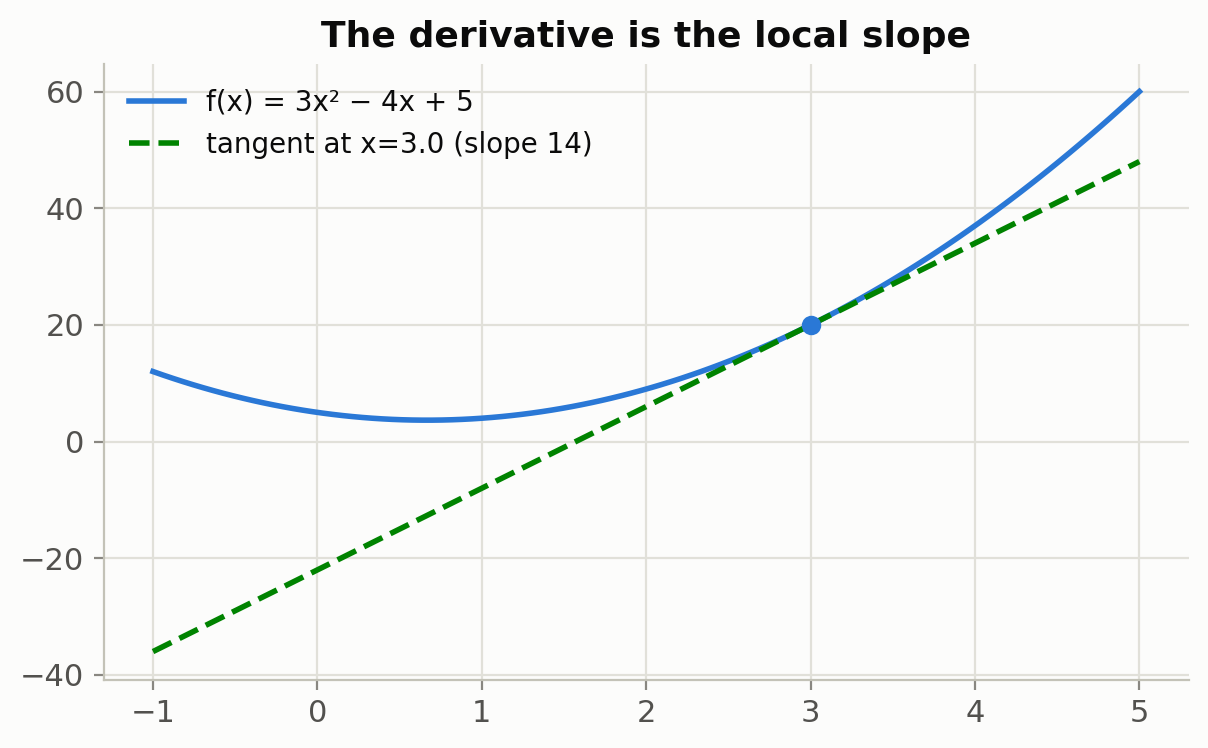

In [3]:
def f(x):
    return 3 * x**2 - 4 * x + 5

x0, eps = 3.0, 1e-6
slope = (f(x0 + eps) - f(x0 - eps)) / (2 * eps)   # central difference
print(f'numeric  df/dx at {x0} = {slope:.6f}')
print(f'analytic 6x - 4 at {x0} = {6 * x0 - 4:.6f}')

xs = np.linspace(-1, 5, 100)
plt.figure(figsize=(7, 4))
plt.plot(xs, f(xs), label='f(x) = 3x² − 4x + 5')
plt.plot(xs, f(x0) + slope * (xs - x0), '--', label=f'tangent at x={x0} (slope {slope:.0f})')
plt.scatter([x0], [f(x0)], zorder=3)
plt.legend()
plt.title('The derivative is the local slope')
plt.show()

## 2. The chain rule, on a graph

Real losses are compositions: `L = g(f(x))`. The chain rule says the sensitivities
*multiply along the path*: `dL/dx = dL/df · df/dx`. Draw the computation as a graph and
the rule becomes mechanical — each node multiplies the gradient flowing in from its output
by its own **local** derivative, and passes the product to its inputs.

Take `L = (a·b + c)²` with `a=2, b=-3, c=10`:

```
a=2 ──┐
      (*)── e=-6 ──┐
b=-3 ─┘            (+)── d=4 ──(**2)── L=16
c=10 ──────────────┘
```

Walk it backward, one local derivative at a time:

In [4]:
a, b, c = 2.0, -3.0, 10.0
e = a * b          # -6
d = e + c          # 4
L = d**2           # 16

dL_dL = 1.0
dL_dd = 2 * d * dL_dL          # local: d(d²)/dd = 2d          → 8
dL_de = 1.0 * dL_dd            # local: d(e+c)/de = 1          → 8
dL_dc = 1.0 * dL_dd            # local: d(e+c)/dc = 1          → 8
dL_da = b * dL_de              # local: d(a·b)/da = b          → -24
dL_db = a * dL_de              # local: d(a·b)/db = a          → 16

print(f'dL/da = {dL_da},  dL/db = {dL_db},  dL/dc = {dL_dc}')

# Trust, but verify — against the nudge oracle:
eps = 1e-6
print('check dL/da =', (((a + eps) * b + c)**2 - ((a - eps) * b + c)**2) / (2 * eps))

dL/da = -24.0,  dL/db = 16.0,  dL/dc = 8.0
check dL/da = -23.99999999891378


Notice what each variable needed to know: **only its own local derivative** and the
gradient handed to it from downstream. Nothing global. That locality is what lets us
automate the whole thing.

## 3. Build the engine: a `Value` that remembers

The plan, in three moves:

1. Each `Value` stores its number (`data`), the values that made it (`_children`), and a
   gradient slot (`grad`).
2. Each *operation* installs a `_backward` closure that does exactly what we did by hand:
   take `out.grad`, multiply by the local derivative, **add** into each input's `grad`.
3. `backward()` visits nodes in reverse topological order — a node's closure runs only
   after every consumer has deposited its share.

Why `+=` and not `=`? If a value is used twice, each use contributes a path, and the total
derivative is the **sum of the paths**. We'll test exactly that case.

In [5]:
class Value:
    """A scalar that remembers how it was computed, so it can backpropagate."""

    def __init__(self, data, _children=(), _op=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._children = _children
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad          # local derivative of + is 1
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad   # d(ab)/da = b
            other.grad += self.data * out.grad   # d(ab)/db = a
        out._backward = _backward
        return out

    def __pow__(self, k):                        # k is a plain number
        out = Value(self.data**k, (self,), f'**{k}')
        def _backward():
            self.grad += k * self.data**(k - 1) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t * t) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # Topological sort: children before parents, so reversed() visits
        # each node only after ALL its consumers have pushed gradient into it.
        topo, visited = [], set()
        def build(v):
            if id(v) not in visited:
                visited.add(id(v))
                for child in v._children:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0                          # dL/dL
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f'Value(data={self.data:.4g}, grad={self.grad:.4g})'

In [6]:
# The graph from section 2, now differentiated automatically:
a, b, c = Value(2.0), Value(-3.0), Value(10.0)
L = (a * b + c) ** 2
L.backward()

print(f'L = {L.data}')
print(f'a: {a}')          # expect grad -24
print(f'b: {b}')          # expect grad  16
print(f'c: {c}')          # expect grad   8

L = 16.0
a: Value(data=2, grad=-24)
b: Value(data=-3, grad=16)
c: Value(data=10, grad=8)


## 4. The bug everyone writes once: `grad =` vs `grad +=`

`b = a + a` uses `a` twice. Both paths contribute `d b/d a = 1`, so the true gradient
is **2**. An engine that *assigns* instead of *accumulating* silently reports 1 — wrong
answers, no crash. The same diamond shape appears everywhere in real models: a weight
reused across a batch, a residual stream feeding both a block and the skip connection.

In [7]:
a = Value(3.0)
(a + a).backward()
print(f'd(a+a)/da = {a.grad}   (both paths counted — with `=` this would be 1.0)')

# Fresh node each backward: gradients accumulate across calls too, which is
# exactly the behavior gradient accumulation (chapter 2.3) exploits on purpose.
# It also means real training loops must zero_grad() between steps.

d(a+a)/da = 2.0   (both paths counted — with `=` this would be 1.0)


## 5. A full neuron, gradchecked

One tanh neuron — `tanh(w1·x1 + w2·x2 + b)` — backpropagated by the engine, every
gradient verified against the nudge oracle from section 1:

In [8]:
def neuron(w1, w2, b, x1=0.5, x2=-1.2):
    return (w1 * x1 + w2 * x2 + b).tanh()

params = {'w1': Value(0.8), 'w2': Value(-0.3), 'b': Value(0.1)}
out = neuron(**params)
out.backward()

eps = 1e-6
print(f'{"param":>5}  {"engine":>12}  {"finite diff":>12}')
for name, p in params.items():
    hi = {k: Value(v.data + (eps if k == name else 0.0)) for k, v in params.items()}
    lo = {k: Value(v.data - (eps if k == name else 0.0)) for k, v in params.items()}
    numeric = (neuron(**hi).data - neuron(**lo).data) / (2 * eps)
    print(f'{name:>5}  {p.grad:12.8f}  {numeric:12.8f}')

param        engine   finite diff
   w1    0.25761263    0.25761263
   w2   -0.61827030   -0.61827030
    b    0.51522525    0.51522525


## 6. The PyTorch bridge

PyTorch's autograd is this algorithm with tensors instead of scalars: same graph
recording, same reverse topological sweep, same accumulate-into-`.grad`. Identical
expression, identical gradients:

In [9]:
# Our engine
a, b, c = Value(2.0), Value(-3.0), Value(10.0)
L = ((a * b + c) ** 2).tanh()
L.backward()

# PyTorch, same expression
at = torch.tensor(2.0, dtype=torch.float64, requires_grad=True)
bt = torch.tensor(-3.0, dtype=torch.float64, requires_grad=True)
ct = torch.tensor(10.0, dtype=torch.float64, requires_grad=True)
Lt = torch.tanh((at * bt + ct) ** 2)
Lt.backward()

for name, ours, theirs in [('a', a, at), ('b', b, bt), ('c', c, ct)]:
    assert abs(ours.grad - theirs.grad.item()) < 1e-8
    print(f'd L/d {name}:  Value {ours.grad:+.10f}   torch {theirs.grad.item():+.10f}')
print('\nSame algorithm. torch just runs it over tensors, on GPUs, in parallel.')

d L/d a:  Value -0.0000000000   torch -0.0000000000
d L/d b:  Value +0.0000000000   torch +0.0000000000
d L/d c:  Value +0.0000000000   torch +0.0000000000

Same algorithm. torch just runs it over tensors, on GPUs, in parallel.


The dictionary between the two, which you can now read in both directions:

| our engine | PyTorch | notes |
|---|---|---|
| `Value(2.0)` | `torch.tensor(2.0, requires_grad=True)` | leaf node |
| `_children`, `_op` | `grad_fn` | the recorded graph |
| `out._backward` closure | a `Function`'s backward | local derivative rule |
| `L.backward()` | `loss.backward()` | reverse topological sweep |
| `p.grad += ...` | `.grad` accumulation | why `optimizer.zero_grad()` exists |
| `p.grad = 0.0` loop | `optimizer.zero_grad()` | reset between steps |

## 7. The engine, packaged

The polished version of this class — with `relu`, `exp`, `log`, division, and reversed
operands — lives in
[`src/ai_playground/fundamentals/autograd.py`](https://github.com/ggreg/ai_playground/blob/main/src/ai_playground/fundamentals/autograd.py),
and `tests/test_fundamentals.py` gradchecks every op against `torch.autograd`. From here
on we import it:

In [10]:
from ai_playground.fundamentals import Value as PackagedValue

a = PackagedValue(2.0)
L = (a * -3.0 + 10.0).tanh() / 2.0 + (0.5 * a).exp()
L.backward()
print(a)

Value(data=2, grad=1.35713)


## Key Takeaways

1. **Reverse mode is the whole trick**: one backward sweep prices a nudge of *every*
   parameter at once — gradients for N parameters at ~the cost of one forward pass,
   which is why training a 7B-parameter model is possible at all
   ([Rumelhart et al., 1986](https://doi.org/10.1038/323533a0)).
2. **Every op is local**: record inputs, define a local derivative, multiply by the
   incoming gradient. ~60 lines cover an MLP's needs.
3. **`grad +=`, never `=`** — shared subexpressions sum their paths. The diamond test
   (`b = a + a` → `a.grad == 2`) catches the classic bug.
4. **Topological order matters**: a node backpropagates only after all its consumers have.
5. **`loss.backward()` is this engine, vectorized** — verified here by `assert` against
   `torch.autograd`, and in `tests/test_fundamentals.py` op by op.
6. A gradient is only useful if you *step* on it. Next:
   [The Training Loop](02_training_loop.ipynb).